# Gradient Descent Parameter Study

This notebook explores a finite-difference gradient descent implementation and visualizes its behavior on simple two-dimensional objective functions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Lab 2 exercise
def finite_difference_gradient(f, x, y, delta):
    grad_x = (f(x + delta, y) - f(x - delta, y)) / (2 * delta)
    grad_y = (f(x, y + delta) - f(x, y - delta)) / (2 * delta)
    return [grad_x, grad_y]

def gradient_descent(f, x, y, learning_rate, delta): 
    f1 = f(x, y)
    position_x, position_y, resultat = [x], [y], [f1]
    
    print(f"Départ : {f1}")
    
    grad = finite_difference_gradient(f, x, y, delta)
    x = x - learning_rate * grad[0]
    y = y - learning_rate * grad[1]
    f2 = f(x, y)
    
    position_x.append(x)
    position_y.append(y)

    
    iterations = 1
    while (f1 - f2) > 1e-9 :
        f1 = f2
        grad = finite_difference_gradient(f, x, y, delta)
        x = x - learning_rate * grad[0]
        y = y - learning_rate * grad[1]
        f2 = f(x, y)
        iterations += 1
        
        position_x.append(x)
        position_y.append(y)
        
    print(f"Fin : {f2:.6f}, itérations = {iterations}")  
    return position_x, position_y


In [3]:
def plot_2d(pos_x, pos_y, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.plot(pos_x, pos_y, color='red', marker='o', markersize=3, linewidth=1.5, label='Trajectory')
    
    ax.set_title(title)
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    
    plt.show()


Départ : 4.5
Fin : 0.000000, itérations = 243


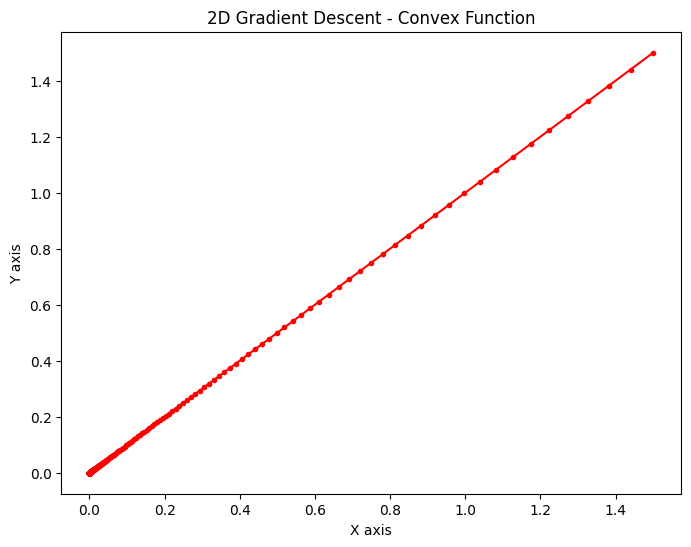

In [4]:
def simple_convex(x, y):
    return x**2 + y**2

pos_x1, pos_y1 = gradient_descent(f=simple_convex, x=1.5, y=1.5, learning_rate=0.02, delta = 0.7)

plot_2d(pos_x1, pos_y1, "2D Gradient Descent - Convex Function")


Départ : 0.489134484959436
Fin : -3.306327, itérations = 96


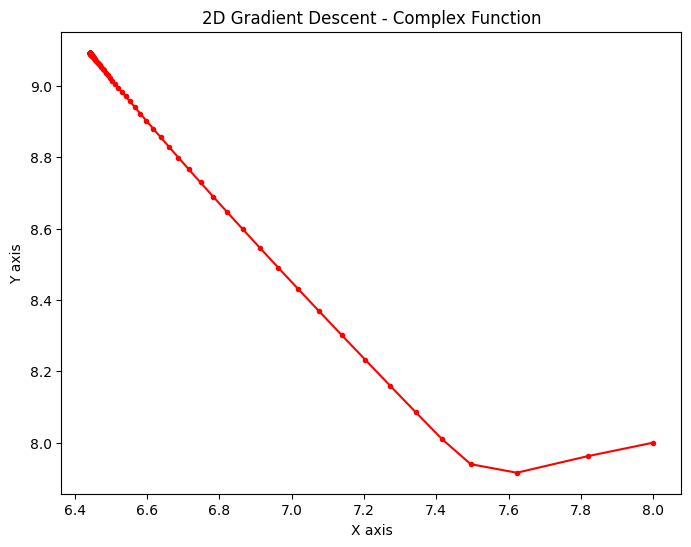

In [6]:
def complex_function(x, y):
    return np.sin(0.83*x) - 1.53 * np.cos(-1.4*y) + np.sin(0.4*x*y)
    
pos_x, pos_y= gradient_descent(f=complex_function, x=8.0, y=8.0, learning_rate=0.05, delta =0.0000900001)

plot_2d(pos_x, pos_y, "2D Gradient Descent - Complex Function")
